In [1]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import patches 


import schemdraw
from schemdraw import flow
import schemdraw as schem
import schemdraw.elements as e
from schemdraw import dsp

%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}pass_zero
</style>
""")

# https://webaudio.github.io/Audio-EQ-Cookbook/audio-eq-cookbook.html
#

# Difference Function

Biquad filters are second order IIR filters with the following difference equation:


$$
h[t] = b_0[n] + b_1 x[n-1]  + b_2 x[n-2] - a_1 y[n-1]  - a_2 y[n-2] 
$$


-----

# Transfer Function


Applying the [z-transform](https://ringbuffer.org/dsp/Digital_Filters/z_transform_filters/) and normalizing for $a_0 = 1$ results in the folowing transfer function:

$$
H(z) = \frac{b_0 + b_1 z^{-1} + b_2 z^{-2}}{1 + a_1 z^{-1} + a_2 z^{-2}}
$$

Hence the name - the transfer function consists of two quadratic functions.u

------

# Poles and Zeros

Since both the numerator and denominator are quadratic polynomials, each with two roots - the filter transfer function has:

- **two poles** 
- **two zeros**


## Factored Product Form

When poles $p_k$ and zeros $z_k$ are known, the transfer function can be expressed as the product 
of  poles and zeros in denominator and numerator  respectively:

$$
H(z) = b_0 \frac{\prod_{k=1}^M (1-z_k z^{-1})}{\prod_{k=1}^N (1-p_k z^{-1})}
$$

## Factoring

$$\begin{eqnarray}
0 & = & a x^2 + b x + c \\
&=& a(x-r)(x-s)
\end{eqnarray}$$

## Quadratic Formula

$$
x = \frac{-b}{2a} \pm \sqrt{b^2 - 4ac}
$$

## Solving (Completing the square)

The solution makes use of the algebraic identity:

$$
a^2 + 2ab + b^2 = (a+b)^2  \\
$$



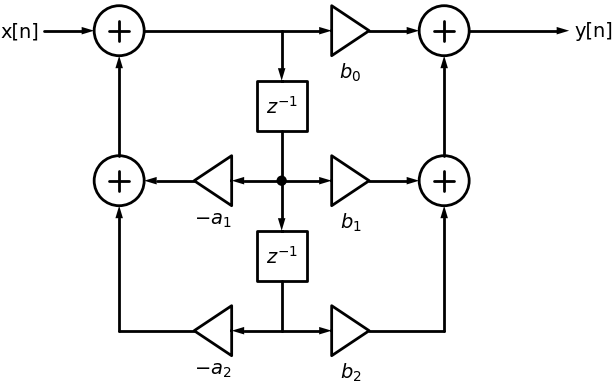

In [2]:
with schemdraw.Drawing() as d:
    d.config(unit=1, fontsize=14)
    dsp.Arrow().length(d.unit).label('x[n]', 'left')
    s1 = dsp.Sum()
    dsp.Line().length(d.unit*2.75)
    
    d.push()
    
    dsp.Arrow().down().length(d.unit)
    dsp.Square().label('$z^{-1}$')
    dsp.Line().length(d.unit)
    
    p1 = dsp.Dot()
    d.push()
    
    d.push()

    dsp.Arrow().left().length(d.unit)
    a1 = dsp.Amp().label('$-a_1$', 'bottom')
    dsp.Arrow()
    s2 = dsp.Sum()
    dsp.Arrow().at(s2.S).up().length(2)

    d.pop()

    dsp.Arrow().down().length(d.unit)
    dsp.Square().label('$z^{-1}$')
    dsp.Line().length(d.unit)
                     
    d.push()
    
    dsp.Arrow().left().length(d.unit)
    a2 = dsp.Amp().label('$-a_2$', 'bottom')
    dsp.Line().length(d.unit*1.5)
    dsp.Arrow().up().length(d.unit*2.5)

    d.pop()
    
    dsp.Arrow().right().length(d.unit)
    b2 = dsp.Amp().label('$b_2$', 'bottom')
    dsp.Line().length(d.unit*1.5)
    dsp.Arrow().up().length(d.unit*2.5)
    s3 = dsp.Sum()
    dsp.Arrow().up().length(d.unit*2)
    s4 = dsp.Sum()
    dsp.Arrow().at(s4.S).right().length(d.unit*2).label('y[n]', 'right')

    d.pop()
    dsp.Arrow().right().length(d.unit)
    b1 = dsp.Amp().label('$b_1$', 'bottom')
    dsp.Arrow().right().length(d.unit)

    d.pop()
    dsp.Arrow().right().length(d.unit)
    b0 = dsp.Amp().label('$b_0$', 'bottom')
    dsp.Arrow().right().length(d.unit)
    
    
   